# ДЗ 2. DQN: Pong и Breakout


## Установка


In [3]:
!pip install -q gymnasium torch matplotlib numpy pillow ale-py
!pip install -q "gymnasium[atari]"
!AutoROM --accept-license


AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [4]:
# import subprocess, sys
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium", "torch", "matplotlib", "numpy", "pillow", "ale-py", "autorom"])
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium[atari]"])
# subprocess.check_call([sys.executable, "-m", "AutoROM", "--accept-license"])

## Визуализация


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output

def show_progress(rewards_batch, log, reward_range=None, loss_batch=None, log_loss=[]):
    if reward_range is None:
        reward_range = [-990, +10]
    mean_reward = np.mean(rewards_batch)
    log.append([mean_reward])
    if not (loss_batch is None):
      mean_loss = np.mean(loss_batch)
      log_loss.append([mean_loss])

    clear_output(True)
    plt.figure(figsize=[8, 4])
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(list(zip(*log))[0], label='Mean rewards')
    ax1.legend(loc=4)
    ax1.grid()

    if not (loss_batch is None):
      ax2 = plt.subplot(1, 2, 2)
      ax2.plot(list(zip(*log_loss))[0], label='Mean loss')
      ax2.legend(loc=4)
      ax2.grid()

    plt.grid()
    plt.grid()
    plt.show()


## Функции: сеть, буфер, шаг оптимизации


In [6]:
import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from collections import deque, namedtuple
import random
import math
from PIL import Image
import os
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward', 'done'))
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, h, w, outputs):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(FRAME_STACK, 32, kernel_size=8, stride=4)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(3136, 512)
        self.fc2 = nn.Linear(512, outputs)

    def forward(self, x):
        x = x.float() / 255.0
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def preprocess_frame(frame):
    img = Image.fromarray(frame)
    img = img.convert('L').resize((84, 84))
    return np.array(img)

class FrameStack:
    def __init__(self, capacity):
        self.frames = deque([], maxlen=capacity)

    def push(self, frame):
        self.frames.append(frame)

    def get_stacked_frames(self):
        return np.stack(self.frames, axis=0)

    def reset(self, initial_frame):
        self.frames.clear()
        for _ in range(FRAME_STACK):
            self.push(initial_frame)

REW_LIST = []

def select_action(state, steps_done):
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)

    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[random.randrange(n_actions)]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)),
                                 device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

    return loss.item()



## Цикл обучения


In [7]:
def train(writer):
    steps_done = 0

    for episode in range(NUM_EPISODES):
        frame, _ = env.reset()
        frame = preprocess_frame(frame)
        frame_stack = FrameStack(FRAME_STACK)
        frame_stack.reset(frame)
        state = torch.tensor(frame_stack.get_stacked_frames(), device=device).unsqueeze(0)

        total_reward = 0
        episode_loss = 0
        num_steps = 0

        while True:
            action = select_action(state, steps_done)
            next_frame, reward, terminated, truncated, _ = env.step(action.item())
            steps_done += 1
            done = terminated or truncated
            total_reward += reward
            reward = torch.tensor([reward], device=device)

            next_frame = preprocess_frame(next_frame)
            frame_stack.push(next_frame)
            if not done:
                next_state = torch.tensor(frame_stack.get_stacked_frames(), device=device).unsqueeze(0)
            else:
                next_state = None

            memory.push(state, action, next_state, reward, torch.tensor([done], device=device))

            state = next_state

            loss = optimize_model()
            if loss is not None:
                episode_loss += loss

            num_steps += 1

            if done:
                break

        if episode % TARGET_UPDATE == 0:
            target_net.load_state_dict(policy_net.state_dict())

        avg_loss = episode_loss / num_steps if num_steps > 0 else 0
        writer.add_scalar('Episode Reward', total_reward, episode)
        writer.add_scalar('Episode Loss', avg_loss, episode)
        writer.add_scalar('Epsilon', EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY), episode)

        print(f'Episode {episode}, Total reward: {total_reward:.2f}, Steps: {num_steps}, Avg loss: {avg_loss:.4f}, Epsilon: {EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY):.4f}')
        REW_LIST.append(total_reward)

    torch.save(policy_net.state_dict(), 'assault_dqn.pth')
    writer.close()
    env.close()



## Pong


In [8]:
NUM_EPISODES = 150
EPS_DECAY = max(50_000, int(100_000 * (NUM_EPISODES / 600)))

### Память 100000, lr 1e-4, batch 32


In [9]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 0.5
EPS_END = 0.02
TARGET_UPDATE = 1000
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)



Episode 0, Total reward: -20.00, Steps: 871, Avg loss: 0.0025, Epsilon: 0.4917
Episode 1, Total reward: -21.00, Steps: 783, Avg loss: 0.0010, Epsilon: 0.4844
Episode 2, Total reward: -21.00, Steps: 882, Avg loss: 0.0006, Epsilon: 0.4763
Episode 3, Total reward: -20.00, Steps: 915, Avg loss: 0.0007, Epsilon: 0.4680
Episode 4, Total reward: -21.00, Steps: 842, Avg loss: 0.0005, Epsilon: 0.4605
Episode 5, Total reward: -21.00, Steps: 821, Avg loss: 0.0006, Epsilon: 0.4533
Episode 6, Total reward: -21.00, Steps: 792, Avg loss: 0.0004, Epsilon: 0.4465
Episode 7, Total reward: -21.00, Steps: 871, Avg loss: 0.0003, Epsilon: 0.4392
Episode 8, Total reward: -20.00, Steps: 977, Avg loss: 0.0009, Epsilon: 0.4310
Episode 9, Total reward: -19.00, Steps: 1126, Avg loss: 0.0005, Epsilon: 0.4219
Episode 10, Total reward: -20.00, Steps: 838, Avg loss: 0.0006, Epsilon: 0.4152
Episode 11, Total reward: -21.00, Steps: 880, Avg loss: 0.0005, Epsilon: 0.4083
Episode 12, Total reward: -20.00, Steps: 870, Avg

In [10]:
pong_m100k_lr1e4 = list(REW_LIST)


### Память 50000, lr 1e-4, batch 32


In [11]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 0.5
EPS_END = 0.02
TARGET_UPDATE = 1000
MEMORY_CAPACITY = 50000
LR = 0.0001

env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)



Episode 0, Total reward: -20.00, Steps: 1038, Avg loss: 0.0024, Epsilon: 0.4901
Episode 1, Total reward: -21.00, Steps: 764, Avg loss: 0.0007, Epsilon: 0.4830
Episode 2, Total reward: -21.00, Steps: 853, Avg loss: 0.0004, Epsilon: 0.4752
Episode 3, Total reward: -21.00, Steps: 931, Avg loss: 0.0006, Epsilon: 0.4668
Episode 4, Total reward: -20.00, Steps: 899, Avg loss: 0.0005, Epsilon: 0.4588
Episode 5, Total reward: -18.00, Steps: 1032, Avg loss: 0.0011, Epsilon: 0.4499
Episode 6, Total reward: -20.00, Steps: 1008, Avg loss: 0.0007, Epsilon: 0.4413
Episode 7, Total reward: -21.00, Steps: 969, Avg loss: 0.0005, Epsilon: 0.4332
Episode 8, Total reward: -20.00, Steps: 895, Avg loss: 0.0004, Epsilon: 0.4259
Episode 9, Total reward: -20.00, Steps: 959, Avg loss: 0.0004, Epsilon: 0.4181
Episode 10, Total reward: -21.00, Steps: 937, Avg loss: 0.0004, Epsilon: 0.4108
Episode 11, Total reward: -20.00, Steps: 838, Avg loss: 0.0005, Epsilon: 0.4043
Episode 12, Total reward: -21.00, Steps: 843, A

In [12]:
pong_m50k_lr1e4 = list(REW_LIST)


### Память 100000, lr 1e-4, batch 128


In [13]:
FRAME_STACK = 4
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.5
EPS_END = 0.02
TARGET_UPDATE = 1000
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)



Episode 0, Total reward: -21.00, Steps: 951, Avg loss: 0.0014, Epsilon: 0.4910
Episode 1, Total reward: -21.00, Steps: 1004, Avg loss: 0.0004, Epsilon: 0.4816
Episode 2, Total reward: -20.00, Steps: 1101, Avg loss: 0.0002, Epsilon: 0.4715
Episode 3, Total reward: -21.00, Steps: 1002, Avg loss: 0.0002, Epsilon: 0.4626
Episode 4, Total reward: -20.00, Steps: 931, Avg loss: 0.0002, Epsilon: 0.4544
Episode 5, Total reward: -17.00, Steps: 1093, Avg loss: 0.0002, Epsilon: 0.4450
Episode 6, Total reward: -21.00, Steps: 932, Avg loss: 0.0003, Epsilon: 0.4372
Episode 7, Total reward: -18.00, Steps: 1028, Avg loss: 0.0002, Epsilon: 0.4287
Episode 8, Total reward: -20.00, Steps: 902, Avg loss: 0.0001, Epsilon: 0.4214
Episode 9, Total reward: -21.00, Steps: 850, Avg loss: 0.0002, Epsilon: 0.4146
Episode 10, Total reward: -21.00, Steps: 843, Avg loss: 0.0001, Epsilon: 0.4080
Episode 11, Total reward: -20.00, Steps: 964, Avg loss: 0.0001, Epsilon: 0.4006
Episode 12, Total reward: -21.00, Steps: 825,

In [14]:
pong_m100k_b128 = list(REW_LIST)


## Breakout


### Память 100000, lr 1e-4, TARGET_UPDATE 500


In [15]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 0.5
EPS_END = 0.02
TARGET_UPDATE = 500
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)



Episode 0, Total reward: 3.00, Steps: 231, Avg loss: 0.0032, Epsilon: 0.4978
Episode 1, Total reward: 2.00, Steps: 204, Avg loss: 0.0023, Epsilon: 0.4958
Episode 2, Total reward: 0.00, Steps: 131, Avg loss: 0.0014, Epsilon: 0.4946
Episode 3, Total reward: 1.00, Steps: 163, Avg loss: 0.0012, Epsilon: 0.4931
Episode 4, Total reward: 1.00, Steps: 176, Avg loss: 0.0006, Epsilon: 0.4914
Episode 5, Total reward: 3.00, Steps: 236, Avg loss: 0.0018, Epsilon: 0.4892
Episode 6, Total reward: 0.00, Steps: 135, Avg loss: 0.0009, Epsilon: 0.4879
Episode 7, Total reward: 1.00, Steps: 197, Avg loss: 0.0008, Epsilon: 0.4861
Episode 8, Total reward: 3.00, Steps: 254, Avg loss: 0.0010, Epsilon: 0.4837
Episode 9, Total reward: 2.00, Steps: 186, Avg loss: 0.0019, Epsilon: 0.4820
Episode 10, Total reward: 1.00, Steps: 152, Avg loss: 0.0016, Epsilon: 0.4806
Episode 11, Total reward: 1.00, Steps: 156, Avg loss: 0.0017, Epsilon: 0.4791
Episode 12, Total reward: 1.00, Steps: 155, Avg loss: 0.0015, Epsilon: 0.4

In [16]:
break_t500 = list(REW_LIST)


### Память 100000, lr 1e-4, TARGET_UPDATE 2000


In [17]:
FRAME_STACK = 4
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 0.5
EPS_END = 0.02
TARGET_UPDATE = 2000
MEMORY_CAPACITY = 100000
LR = 0.0001

env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
n_actions = env.action_space.n

init_frame = preprocess_frame(env.reset()[0])
h, w = init_frame.shape
policy_net = DQN(h, w, n_actions).to(device)
target_net = DQN(h, w, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
memory = ReplayMemory(MEMORY_CAPACITY)

REW_LIST.clear()
log_dir = f"runs/exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(log_dir)
train(writer)



Episode 0, Total reward: 2.00, Steps: 215, Avg loss: 0.0031, Epsilon: 0.4979
Episode 1, Total reward: 3.00, Steps: 249, Avg loss: 0.0043, Epsilon: 0.4956
Episode 2, Total reward: 1.00, Steps: 165, Avg loss: 0.0024, Epsilon: 0.4940
Episode 3, Total reward: 1.00, Steps: 184, Avg loss: 0.0010, Epsilon: 0.4923
Episode 4, Total reward: 0.00, Steps: 143, Avg loss: 0.0006, Epsilon: 0.4909
Episode 5, Total reward: 5.00, Steps: 304, Avg loss: 0.0017, Epsilon: 0.4881
Episode 6, Total reward: 0.00, Steps: 144, Avg loss: 0.0013, Epsilon: 0.4867
Episode 7, Total reward: 0.00, Steps: 129, Avg loss: 0.0010, Epsilon: 0.4855
Episode 8, Total reward: 1.00, Steps: 185, Avg loss: 0.0009, Epsilon: 0.4838
Episode 9, Total reward: 2.00, Steps: 208, Avg loss: 0.0008, Epsilon: 0.4819
Episode 10, Total reward: 2.00, Steps: 224, Avg loss: 0.0009, Epsilon: 0.4798
Episode 11, Total reward: 2.00, Steps: 221, Avg loss: 0.0007, Epsilon: 0.4778
Episode 12, Total reward: 1.00, Steps: 177, Avg loss: 0.0004, Epsilon: 0.4

In [18]:
break_t2000 = list(REW_LIST)


## Графики


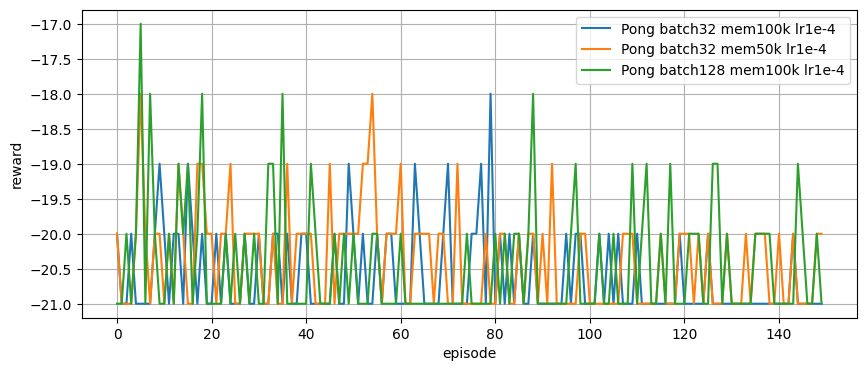

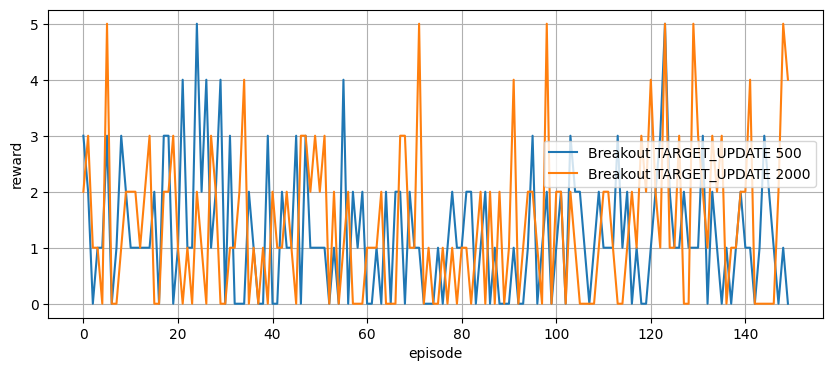

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(pong_m100k_lr1e4, label='Pong batch32 mem100k lr1e-4')
plt.plot(pong_m50k_lr1e4, label='Pong batch32 mem50k lr1e-4')
plt.plot(pong_m100k_b128, label='Pong batch128 mem100k lr1e-4')
plt.xlabel('episode')
plt.ylabel('reward')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(break_t500, label='Breakout TARGET_UPDATE 500')
plt.plot(break_t2000, label='Breakout TARGET_UPDATE 2000')
plt.xlabel('episode')
plt.ylabel('reward')
plt.legend()
plt.grid(True)
plt.show()


## Выводы

- Длина прогона: `NUM_EPISODES = 150` и масштабированный `EPS_DECAY` (ячейка под Pong) укладывают пять запусков примерно в ~1 ч на типичной GPU; при перерасходе времени уменьшите до 120 эпизодов или уберите один абляционный блок Pong.
- Базовый прогон по DeepMind 2015: batch 32 при mem 100k и lr 1e-4; вторая кривая на Pong — тот же lr и буфер, но batch 128: сравнивается дисперсия градиента и скорость шага оптимизации относительно статьи.
- Память 50k при batch 32: буфер быстрее перезаписывается, выборка в мини-батчах менее разнообразна, чем при 100k.
- Breakout: batch 32; сравниваются два TARGET_UPDATE; в коде семинара обновление target привязано к номеру эпизода.
